In [2]:
import pybedtools, os, re, pickle, math
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec
import itertools

In [3]:
sns.set(style='whitegrid', rc={"figure.dpi":100, 'savefig.dpi':300})  
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = ['Arial', 'sans-serif']

In [6]:
df_within = pd.read_csv('01_inputfiles/hint_within_replicate.csv.gz', sep=",") 
ref_df = pd.read_csv('01_inputfiles/hint_across_cellline.csv.gz', sep=",") 

df_across = pd.read_csv('01_inputfiles/hint_across_replicate.csv.gz', sep=",") 
df_across[["cond1", "cond2"]] = df_across['condition'].str.split('_', n=1, expand=True)
df_across["cond1"] = df_across["cond1"].str[1:].astype(float)
df_across["cond2"] = df_across["cond2"].str[1:].astype(float)
mask = df_across['cond2'] > df_across['cond1']
df_across.loc[mask, "fold_change"] = df_across.loc[mask, "fold_change"] * -1

display(df_across)



,Motif,cellline,comparison,P_values,Z_score,TF_Activity,fold_change,-log10(pvalue),condition,sampling_type,cond1,cond2
0,MA0657.1.KLF13,MCF7,r1e7_r5e7,0.073760,1.788099,0.007050,0.020837,1.132178,r1e7_r5e7,r,10000000.0,50000000.0
1,MA1110.2.Nr1H4,MCF7,r1e7_r5e7,0.611375,0.508111,0.001581,0.023341,0.213692,r1e7_r5e7,r,10000000.0,50000000.0
2,MA1726.1.ZNF331,MCF7,r1e7_r5e7,0.397577,0.845957,0.003024,0.032738,0.400579,r1e7_r5e7,r,10000000.0,50000000.0
3,MA0857.1.Rarb,MCF7,r1e7_r5e7,0.800814,0.252294,0.000488,0.005373,0.096468,r1e7_r5e7,r,10000000.0,50000000.0
4,MA0842.2.NRL,MCF7,r1e7_r5e7,0.911164,-0.111571,-0.001067,-0.010350,0.040404,r1e7_r5e7,r,10000000.0,50000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
162308,MA1419.1.IRF4,HEPG2,r1e6_r5e6,0.149760,1.440380,0.002661,0.120963,0.824604,r1e6_r5e6,r,1000000.0,5000000.0
162309,MA0871.2.TFEC,HEPG2,r1e6_r5e6,0.673294,0.421631,0.000811,0.021091,0.171795,r1e6_r5e6,r,1000000.0,5000000.0
162310,MA0081.2.SPIB,HEPG2,r1e6_r5e6,0.938083,0.077679,0.000186,0.004620,0.027759,r1e6_r5e6,r,1000000.0,5000000.0
162311,MA1139.1.FOSL2::JUNB,HEPG2,r1e6_r5e6,0.728291,-0.347400,-0.000587,-0.015520,0.137695,r1e6_r5e6,r,1000000.0,5000000.0


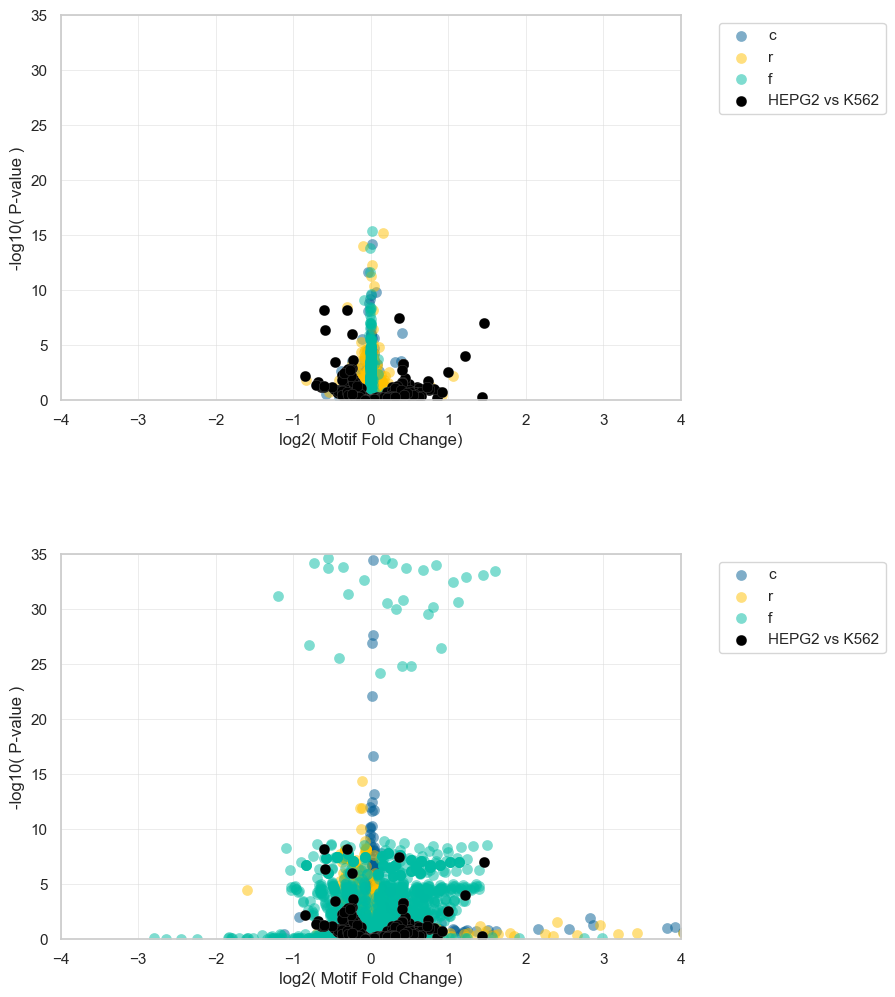

In [8]:
#color_scheme_st = {"c":"#CE3B59", "f":"#F5C23C", "r":"#993CBE"}
color_scheme_st = {"c":"#005D93", "f":"#00BBA2", "r":"#ffc000", "b":"black"}

fig = plt.figure(figsize=(8, 12))
gs = GridSpec(2, 1, figure=fig, hspace=0.4)

cl = "K562"
myy='-log10(pvalue)'
myx='fold_change'

ax0 = fig.add_subplot(gs[0])  
ax1 = fig.add_subplot(gs[1]) 

for st in ["c", "r", "f"]:
    cond1 = (df_within.cellline == cl)
    cond2 = (df_within.sampling_type == st)
    cond3 = (df_within.comparison == "rep1_rep2")
    sns.scatterplot(data=df_within[cond1 & cond2 & cond3].copy().reset_index(),  
                    x=myx, y=myy, 
                    color=color_scheme_st[st], 
                    alpha=0.5,
                    linewidth=0,
                    rasterized=True,
                    s=60, ax=ax0,
                    label=st)

    cond1 = (df_across.cellline == cl)
    cond2 = (df_across.sampling_type == st)
    sns.scatterplot(data=df_across[cond1 & cond2].copy().reset_index(), 
                    x=myx, y=myy, 
                    color=color_scheme_st[st], 
                    alpha=0.5,
                    linewidth=0,
                    rasterized=True,
                    s=60, ax=ax1,
                    label=st)


sns.scatterplot(data=ref_df, x=myx, y=myy,  
                color="black", 
                edgecolor="#CCCCCC", 
                linewidth=0.1,
                s=60, ax=ax0, 
                label="HEPG2 vs K562")
sns.scatterplot(data=ref_df, x=myx, y=myy,  
                color="black", 
                edgecolor="#CCCCCC", 
                linewidth=0.1,
                s=60, ax=ax1, 
                label="HEPG2 vs K562")


ax0.set_ylim(0, 35)
ax1.set_ylim(0, 35)
ax0.set_xlim(-4, 4)
ax1.set_xlim(-4, 4)

ax0.set_xlabel("log2( Motif Fold Change)")
ax0.set_ylabel("-log10( P-value )")
ax1.set_xlabel("log2( Motif Fold Change)")
ax1.set_ylabel("-log10( P-value )")

ax0.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax0.grid(which='major', color='#DDDDDD', linewidth=0.4)
ax1.grid(which='major', color='#DDDDDD', linewidth=0.4)

plt.show()

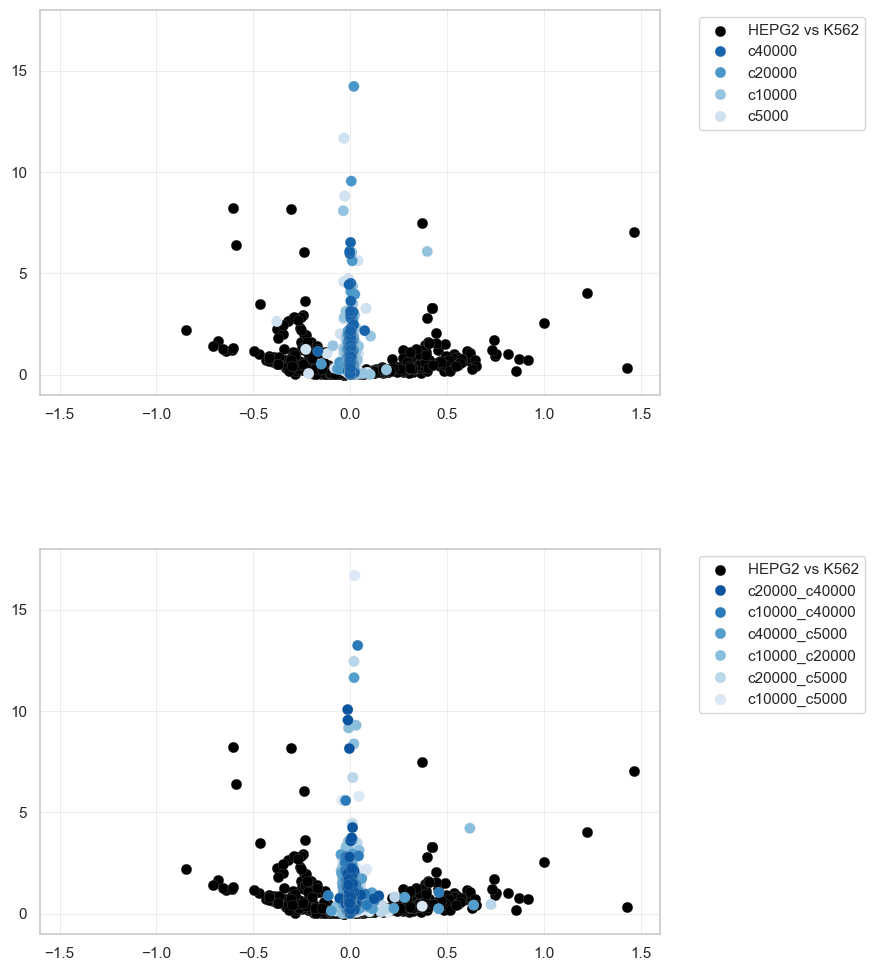

In [9]:
fig = plt.figure(figsize=(8, 12))
gs = GridSpec(2, 1, figure=fig, hspace=0.4)

cl = "K562"
myy='-log10(pvalue)'
myx='fold_change'

ax0 = fig.add_subplot(gs[0])  
ax1 = fig.add_subplot(gs[1]) 

sns.scatterplot(data=ref_df, x=myx, y=myy,  
                color="black", 
                edgecolor="#CCCCCC", linewidth=0.1, 
                #linewidth=0, rasterized=True,
                s=60, ax=ax0, 
                label="HEPG2 vs K562")
sns.scatterplot(data=ref_df, x=myx, y=myy,  
                color="black", 
                edgecolor="#CCCCCC", linewidth=0.1, 
                #linewidth=0, rasterized=True,
                s=60, ax=ax1, 
                label="HEPG2 vs K562")


selected = ["c40000", "c20000", "c10000", "c5000"]
cond1 = (df_within.cellline == cl)
cond2 = (df_within.sampling_type=="c")
cond3 = (df_within.comparison=="rep1_rep2")
cond4 = (df_within.condition.isin(selected))
tmp = df_within[cond1 & cond2 & cond3 & cond4].copy().reset_index()
tmp["condition"] = pd.Categorical(tmp["condition"], categories=selected, ordered=True)
tmp = tmp.sort_values("condition", ascending=False)

sns.scatterplot(data=tmp, x=myx, y=myy,  
                hue='condition',
                palette = "Blues_r",
                hue_order = selected,
                linewidth=0.1, edgecolor="#CCCCCC", 
                #linewidth=0, 
                rasterized=True,
                s=60, ax=ax0)

selected = ['c20000_c40000', 'c10000_c40000', 'c40000_c5000', 'c10000_c20000', 'c20000_c5000','c10000_c5000']
cond1 = (df_across.cellline == cl)
cond2 = (df_across.sampling_type=="c")
cond4 = (df_across.condition.isin(selected))
tmp = df_across[cond1 & cond2 & cond4].copy().reset_index()
tmp["condition"] = pd.Categorical(tmp["condition"], categories=selected, ordered=True)
tmp = tmp.sort_values("condition", ascending=False)
sns.scatterplot(data=tmp, x=myx, y=myy,  
                hue='condition',
                palette = "Blues_r",
                hue_order = selected,
                linewidth=0.1, edgecolor="#CCCCCC", 
                #linewidth=0, 
                rasterized=True,
                s=60, ax=ax1)


ax0.set_ylim(-1, 18)
ax1.set_ylim(-1, 18)
ax0.set_yticks([0, 5, 10, 15])
ax1.set_yticks([0, 5, 10, 15])

ax0.set_xlim(-1.6, 1.6)
ax1.set_xlim(-1.6, 1.6)

ax0.set_ylabel(""); ax0.set_xlabel("")
ax1.set_ylabel(""); ax1.set_xlabel("")

ax0.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax0.grid(which='major', color='#DDDDDD', linewidth=0.4)
ax1.grid(which='major', color='#DDDDDD', linewidth=0.4)

plt.show()